In [78]:
# Center source alibration data and miniPET geometry directories
center_source_data_dir = 'C:/Users/burri/Downloads/MiniPET_Test_100mm_15min_coinc.dat'
miniPET_geo_map_dir = 'C:/Users/burri/Downloads/testMiniPETmap.csv' # Only used if generate_coincidence_heatmaps = True
output_dir = 'C:/Users/burri/Downloads/calibrationtest'

# Use gaussian fit to find mean for time offset, otherwise use simple weighted average around max
use_guassian_fit = True
# Sample size threshold, will only perform fit or weighted average for each table entry if sample size is above this value
sample_size_threshold = 0


import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [79]:
# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv(center_source_data_dir, usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=10000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Convert Left channel to mod 128
    chunk['IDL'] = chunk['IDL'] % 128
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeR'] - chunk['TimeL']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr = df.to_numpy()

print(arr[0])

[775837807984           23 775837808245          110          261]


In [45]:
# Geometric time offset matrix, stores time difference corresponding to the geometric center for each LOR
# MiniPET should be all 0
# each row corresponds to a left channel, each col to a right channel, such that each entry is a unique LOR
geometric_time_offsets = [[0 for i in range(128)] for j in range(128)]

# Read map
mapdf = pd.read_csv(miniPET_geo_map_dir, usecols=[1,2,3], header=None)
map = mapdf.to_numpy()

# For testing:
#for x in range(128):
#    map[x][0] = map[x][0] + 50

for l in range(128):
    for r in range(128):

        xL, yL, zL = map[l]
        xR, yR, zR = map[r+128]
        # Get midpoint between two channels
        mX, mY, mZ = (xL+xR)/2, (yL+yR)/2, (zL+zR)/2

        # If midpoint lies on x = 0, write to table
        if mX == 0:
            geometric_time_offsets[l][r] = 0
        # else need to calculate distance between x = 0 and midpoint along LOR
        else:
            # Parameterize, below are slopes with x being the parameter
            ay, az = (yR-yL)/(xR-xL), (zR-zL)/(xR-xL)
            # Find y and z for positive distance xL away from xL (x = 0)
            y0, z0 = yL + ay * -1 * xL, zL + az * -1 * xL
            # Distance, converted to light picoseconds
            d = ((mX)**2 + (y0-mY)**2 + (z0-mZ)**2)**0.5 / 0.299792458 #mm/ps
            # Find direction (midpoint left or right from x=0)
            if -1 * xL > xR:
                geometric_time_offsets[l][r] = -1 * d
            else:
                geometric_time_offsets[l][r] = d

#print(geometric_time_offsets)

In [46]:
xL, yL, zL = -15, 2, 4
xR, yR, zR = 10, -2, -4
# Get midpoint between two channels
mX, mY, mZ = (xL+xR)/2, (yL+yR)/2, (zL+zR)/2

# If midpoint lies on x = 0, write to table
if mX == 0:
    geometric_time_offsets[l][r] = 0
# else need to calculate distance between x = 0 and midpoint along LOR
else:
    # Parameterize, below are slopes with x being the parameter
    ay, az = (yR-yL)/(xR-xL), (zR-zL)/(xR-xL)
    # Find y and z for positive distance xL away from xL (x = 0)
    y0, z0 = yL + ay * -1 * xL, zL + az * -1 * xL
print(y0, z0)

-0.3999999999999999 -0.7999999999999998


In [ ]:
# Matrix for storing ARRAYS of coincidences, adjusted for geometric offset
# each row corresponds to a left channel, each col to a right channel, 
# so then each entry is a unique LOR 
coincidences_matrix = [[[] for i in range(128)] for j in range(128)]

# Creates coincidence matrix containing TimeDiffs (relative to x=0) for every LOR 
for row in arr:
    geometric_time_offset = geometric_time_offsets[int(row[1])][int(row[3])]
    coincidences_matrix[int(row[1])][int(row[3])].append(row[4] + geometric_time_offset)

# Create master time difference array
master_time_diffs = []
for x in arr:
    master_time_diffs.append(x[4])


In [58]:
print(len(master_time_diffs))

866394


In [71]:
# Array for storing left and right module channel time offsets, these will be used to calculate per channel offset values
coincidences_arr_l = [[] for i in range(128)]
coincidences_arr_r = [[] for i in range(128)]

# Fill arrays
for l in range(128):
    for r in range(128):
        coincidences_arr_l[l].extend(coincidences_matrix[l][r])
        coincidences_arr_r[r].extend(coincidences_matrix[l][r])

In [72]:
# Create lookup table for each channel in l and r
lookup_l = np.asarray([0.0 for i in range(128)])
lookup_r = np.asarray([0.0 for i in range(128)])

# Define gaussian fit
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Left side
for l in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_l[l] = -1 * popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

# Right side
for r in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_r[r], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_r[r] = -1 * popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

C:\Users\burri\AppData\Local\Temp\ipykernel_22516\837447302.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]


In [75]:
# Create master time diff array calibrated
master_time_diffs_calibrated = []

for x in arr:
    master_time_diffs_calibrated.append(x[4] + lookup_l[x[1]] + lookup_r[x[3]])

In [ ]:
def do():

# Creates coincidence matrix containing TimeDiffs (relative to x=0) for every LOR 
    for row in arr:
        geometric_time_offset = geometric_time_offsets[int(row[1])][int(row[3])]
        coincidences_matrix[int(row[1])][int(row[3])].append(row[4] + geometric_time_offset)

# Create master time difference array
    master_time_diffs = []
    for x in arr:
        master_time_diffs.append(x[4])

# Array for storing left and right module channel time offsets, these will be used to calculate per channel offset values
    coincidences_arr_l = [[] for i in range(128)]
    coincidences_arr_r = [[] for i in range(128)]

# Fill arrays
    for l in range(128):
        for r in range(128):
            coincidences_arr_l[l].extend(coincidences_matrix[l][r])
            coincidences_arr_r[r].extend(coincidences_matrix[l][r])

    # Create lookup table for each channel in l and r
    lookup_l = np.asarray([0.0 for i in range(128)])
    lookup_r = np.asarray([0.0 for i in range(128)])

# Define gaussian fit
    def gaussian(x, a, mu, c):
        return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Left side
    for l in range(128):
#for l in [0]:
    # Create histogram
        counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
    # Initial guess for amplitude
        inita = 0.8 * np.max(counts)
    # Initial guess for mean
        initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
        try:
        # try fit, with bad stats the fit sometimes doesn't work
            popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
            if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
                lookup_l[l] = -1 * popt[1]
        except:
            pass

# Right side
    for r in range(128):
#for l in [0]:
    # Create histogram
        counts, bins = np.histogram(coincidences_arr_r[r], bins = 200)
    # Initial guess for amplitude
        inita = 0.8 * np.max(counts)
    # Initial guess for mean
        initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
        try:
        # try fit, with bad stats the fit sometimes doesn't work
            popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
            if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
                lookup_r[r] = -1 * popt[1]
        except:
            pass


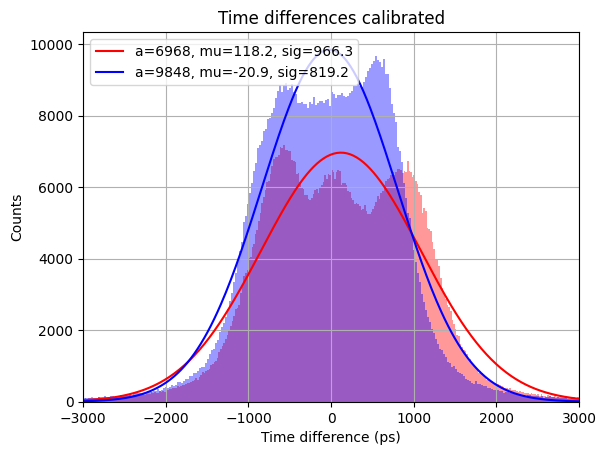

In [76]:
def formatlabel(a, mu, c):
        return f'a={round(a)}, mu={round(mu,1)}, sig={round(abs(c),1)}'

# Histogram before time calibration
hist_before = plt.hist(master_time_diffs, bins = 1000, color = 'red', alpha = 0.4)
bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
popt0 = curve_fit(gaussian, bincenters0, hist_before[0], p0 = [6000, 0, 1000])[0]
#print(*popt0)
plt.plot(np.linspace(-3000, 3000, 300), gaussian(np.linspace(-3000, 3000, 300), *popt0), color = 'red', label = formatlabel(*popt0))
    
# Histogram after time calibration
hist_after = plt.hist(master_time_diffs_calibrated, bins = 1000, color = 'blue', alpha = 0.4)
bincenters1 = [(hist_after[1][x]+hist_after[1][x+1])/2 for x in range(len(hist_after[0]))]
popt1 = curve_fit(gaussian, bincenters1, hist_after[0], p0 = [6000, 0, 1000])[0]
#print(*popt1)
plt.plot(np.linspace(-3000, 3000, 300), gaussian(np.linspace(-3000, 3000, 300), *popt1), color = 'blue', label = formatlabel(*popt1))

plt.legend()
plt.grid()
plt.xlim(-3000, 3000)
plt.title('Time differences calibrated')
plt.xlabel('Time difference (ps)')
plt.ylabel('Counts')
plt.show()
#plt.savefig(output_dir + '/time_diffence_histograms.png')
plt.close()